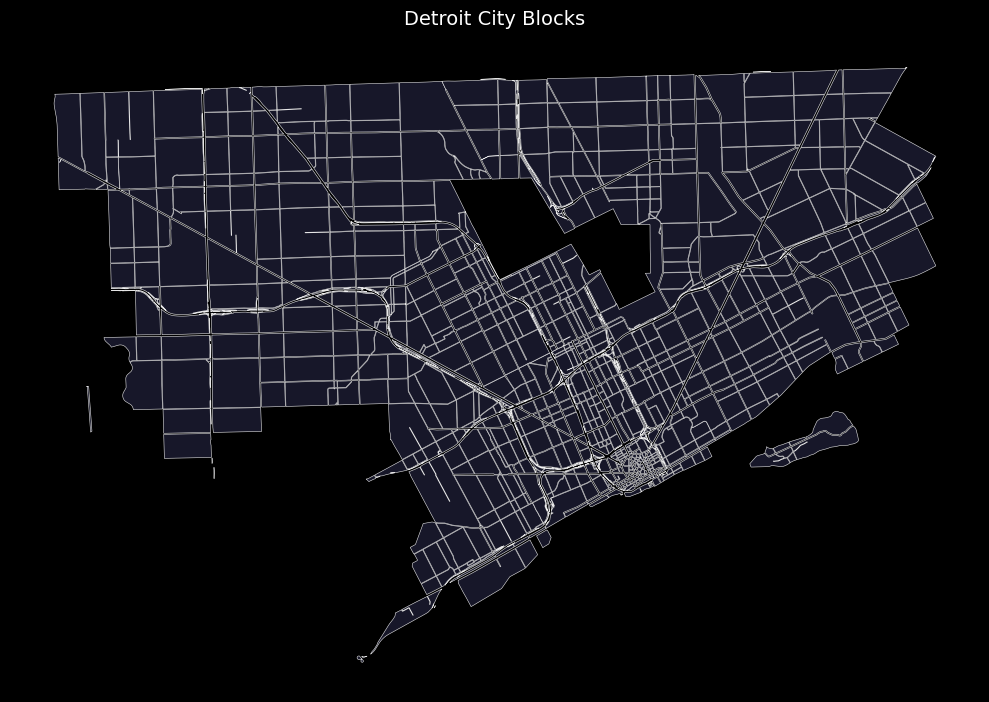

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

blocks = gpd.read_file("data/blocks.geojson")

fig, ax = plt.subplots(figsize=(10, 9), facecolor="black")
ax.set_facecolor("black")
blocks.plot(ax=ax, facecolor="#1a1a2e", edgecolor="white", linewidth=0.4, alpha=0.9)
ax.set_axis_off()
plt.title("Detroit City Blocks", color="white", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
from shapely.geometry import LineString

# ── 1. Project to UTM 17N for metric length/area ──────────────────────────────
road_buf = gpd.read_file("data/road_buffer.geojson")
UTM = "EPSG:32617"
blk = blocks.to_crs(UTM).copy()
rb  = road_buf[["geometry", "num_aadt"]].to_crs(UTM).copy()
rb["num_aadt"] = pd.to_numeric(rb["num_aadt"], errors="coerce").fillna(0)

# ── 2. Extract every polygon edge with a stable edge_id ───────────────────────
records = []
for blk_idx, row in blk.iterrows():
    coords = list(row.geometry.exterior.coords)
    for i in range(len(coords) - 1):
        edge = LineString([coords[i], coords[i + 1]])
        records.append({"block_idx": blk_idx, "geometry": edge, "edge_len": edge.length})

edges_gdf = gpd.GeoDataFrame(records, geometry="geometry", crs=UTM)
edges_gdf["edge_id"] = range(len(edges_gdf))   # stable unique id for dedup

# ── 3. Spatial join: all (edge, road_buffer) pairs that intersect ─────────────
rb_indexed = rb.reset_index(names="rb_idx")
joined = gpd.sjoin(
    edges_gdf,
    rb_indexed,
    how="left",
    predicate="intersects"
)
joined = joined.dropna(subset=["rb_idx"])
joined["rb_idx"] = joined["rb_idx"].astype(int)

# ── 4. Intersection length → keep the road buffer with the longest overlap ────
# Re-attach road buffer geometry so we can compute edge ∩ road_polygon
joined = joined.join(rb.geometry.rename("rb_geom"), on="rb_idx")

joined["isect_len"] = joined.apply(
    lambda r: r["geometry"].intersection(r["rb_geom"]).length, axis=1
)

# For each edge, keep only the single best-matching road buffer
best = (
    joined[joined["isect_len"] > 0]
    .sort_values("isect_len", ascending=False)
    .drop_duplicates(subset=["edge_id"])
)

# ── 5. Aggregate: Σ(edge_len × AADT) / block_area ────────────────────────────
best["contribution"] = best["edge_len"] * best["num_aadt"]
block_sums = best.groupby("block_idx")["contribution"].sum()

blk["block_area"]       = blk.geometry.area
blk["traffic_exposure"] = (block_sums / blk["block_area"]).reindex(blk.index).fillna(0)

print(blk["traffic_exposure"].describe())


count      1270.000000
mean       2344.398537
std        7344.256367
min           3.215798
25%          44.170249
50%         118.904912
75%         984.672837
max      156301.748543
Name: traffic_exposure, dtype: float64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 9), facecolor="black")
ax.set_facecolor("black")
blk.plot(
    ax=ax,
    column="traffic_exposure",
    cmap="YlOrRd",
    scheme="quantiles",
    k=7,
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#222222", "label": "No data"},
    legend_kwds={"title": "AADT·m / m² (quantiles)", "fmt": "{:.0f}"}
)
ax.set_axis_off()
plt.title("Traffic Exposure per Block  [Σ(edge·AADT) / area]", color="white", fontsize=13)
plt.tight_layout()
plt.show()


## Regression: LST ~ Traffic Exposure + Impervious + NDBI + NDVI

In [ ]:
import rasterio
import numpy as np
from rasterstats import zonal_stats

# ── 1. Load rasters ───────────────────────────────────────────────────────────
RASTERS = {
    "lst":        "data/detroit_lst_summer2024.tif",
    "impervious": "data/detroit_impervious_nlcd2021.tif",
    "ndbi":       "data/detroit_ndbi_summer2024.tif",
    "ndvi":       "data/detroit_ndvi_summer2024.tif",
    "water":      "data/detroit_water_jrc.tif",
}

raster_data = {}
raster_meta = {}
for name, path in RASTERS.items():
    with rasterio.open(path) as src:
        raster_data[name] = src.read(1).astype(np.float32)
        raster_meta[name] = src.meta.copy()
        raster_meta[name]["transform"] = src.transform

print("Rasters loaded:", list(raster_data.keys()))


In [ ]:
from rasterio.warp import reproject, Resampling

# ── 2. Align all rasters to LST grid (common reference) ──────────────────────
with rasterio.open("data/detroit_lst_summer2024.tif") as ref:
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_shape     = (ref.height, ref.width)

def resample_to_lst(arr, src_meta):
    """Resample arr to match LST raster grid using nearest-neighbour."""
    dst = np.full(ref_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr.astype(np.float32),
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

aligned = {name: resample_to_lst(raster_data[name], raster_meta[name])
           for name in ["lst", "impervious", "ndbi", "ndvi", "water"]}

# ── Water mask: pixels where water == 1 → NaN in every analysis layer ────────
water_mask = aligned["water"] > 0.5

masked = {}
for name in ["lst", "impervious", "ndbi", "ndvi"]:
    arr = aligned[name].copy()
    arr[water_mask] = np.nan
    masked[name] = arr

print("Aligned shape:", ref_shape, "| water pixels masked:", water_mask.sum())

# ── 3. Zonal statistics (mean per block, water-excluded) ─────────────────────
from rasterstats import zonal_stats

blk_4326 = blk.to_crs("EPSG:4326")

def zonal_mean(arr, geodf):
    stats = zonal_stats(
        geodf, arr,
        affine=ref_transform,
        stats=["mean"],
        nodata=np.nan,
        all_touched=False,
    )
    return [s["mean"] for s in stats]

for name in ["lst", "impervious", "ndbi", "ndvi"]:
    blk_4326[name] = zonal_mean(masked[name], blk_4326)
    blk[name] = blk_4326[name].values

print(blk[["traffic_exposure", "lst", "impervious", "ndbi", "ndvi"]].describe())


In [48]:
import statsmodels.api as sm

# ── 4. Regression: LST ~ traffic_exposure + impervious + ndbi + ndvi ──────────
FEATURES = ["traffic_exposure", "impervious", "ndbi", "ndvi"]
TARGET   = "lst"

reg_df = blk[FEATURES + [TARGET]].dropna()
print(f"Blocks used in regression: {len(reg_df)} / {len(blk)}")

X = sm.add_constant(reg_df[FEATURES])
y = reg_df[TARGET]

model = sm.OLS(y, X).fit()
print(model.summary())


Blocks used in regression: 1240 / 1270
                            OLS Regression Results                            
Dep. Variable:                    lst   R-squared:                       0.645
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     560.8
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          8.26e-276
Time:                        21:11:23   Log-Likelihood:                -2223.5
No. Observations:                1240   AIC:                             4457.
Df Residuals:                    1235   BIC:                             4483.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
c

In [49]:
import statsmodels.api as sm

# ── Simple regression: LST ~ traffic_exposure only ───────────────────────────
reg_simple = blk[["traffic_exposure", "lst"]].dropna()
print(f"Blocks used: {len(reg_simple)} / {len(blk)}")

X_simple = sm.add_constant(reg_simple["traffic_exposure"])
model_simple = sm.OLS(reg_simple["lst"], X_simple).fit()
print(model_simple.summary())


Blocks used: 1240 / 1270
                            OLS Regression Results                            
Dep. Variable:                    lst   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7210
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.396
Time:                        21:11:28   Log-Likelihood:                -2865.1
No. Observations:                1240   AIC:                             5734.
Df Residuals:                    1238   BIC:                             5745.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const          

/var/folders/5z/7y4fq24d761794_v8h19r9xh0000gn/T/ipykernel_17812/3617342166.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


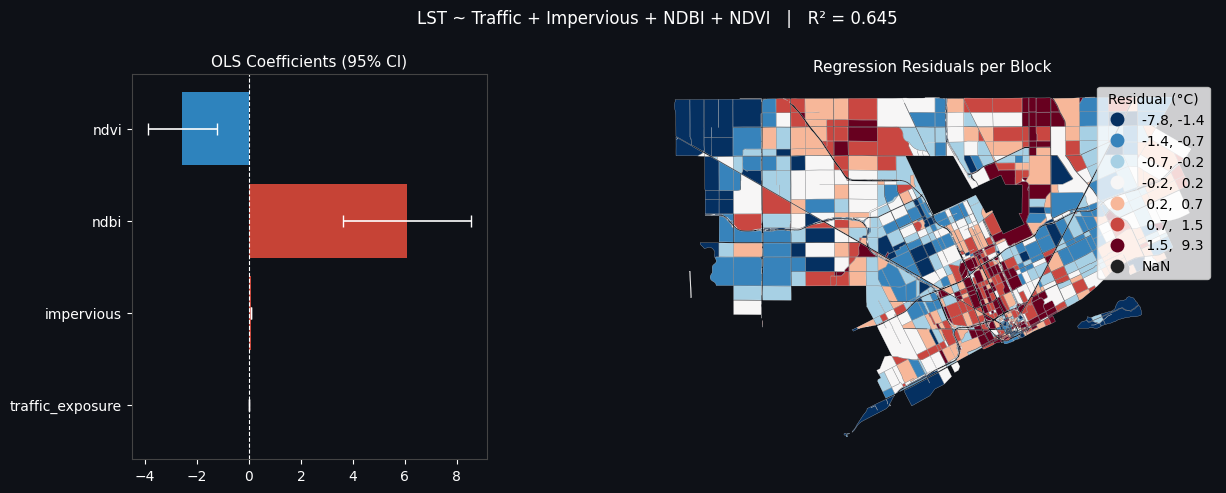

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 5. Coefficient plot + residual map ────────────────────────────────────────
coefs = model.params.drop("const")
cis   = model.conf_int().drop("const")

fig = plt.figure(figsize=(14, 5), facecolor="#0e1117")
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.6], wspace=0.35)

# — Coefficient plot —
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor("#0e1117")
colors = ["#e74c3c" if v > 0 else "#3498db" for v in coefs]
ax1.barh(coefs.index, coefs.values, color=colors, alpha=0.85)
ax1.errorbar(
    coefs.values, coefs.index,
    xerr=[(coefs - cis[0]).values, (cis[1] - coefs).values],
    fmt="none", color="white", linewidth=1.2, capsize=4
)
ax1.axvline(0, color="white", linewidth=0.8, linestyle="--")
ax1.set_title("OLS Coefficients (95% CI)", color="white", fontsize=11)
ax1.tick_params(colors="white")
for spine in ax1.spines.values():
    spine.set_edgecolor("#444")

# — Residual map —
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor("black")
blk_plot = blk.copy()
blk_plot["residual"] = np.nan
blk_plot.loc[reg_df.index, "residual"] = model.resid.values

blk_plot.plot(
    ax=ax2, column="residual", cmap="RdBu_r",
    scheme="quantiles", k=7,
    linewidth=0.15, edgecolor="white",
    legend=True,
    missing_kwds={"color": "#222222"},
    legend_kwds={"title": "Residual (°C)", "fmt": "{:.1f}"}
)
ax2.set_axis_off()
ax2.set_title("Regression Residuals per Block", color="white", fontsize=11)

plt.suptitle(
    f"LST ~ Traffic + Impervious + NDBI + NDVI   |   R² = {model.rsquared:.3f}",
    color="white", fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()